# Decision Tree #

In [114]:
# import libraries:
import pandas as pd
# Read .csv:
dataset = pd.read_csv('insurance_pre.csv')
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [115]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [116]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [117]:
dataset.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
charges     float64
dtype: object

In [118]:
# Pre_Processing:
# 1.Missing value 
# 2.check the outlier
# 3.Convert categorical columns. 

In [119]:
# convert categorical data:
dataset = pd.get_dummies(dataset,drop_first = True,dtype = int)
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


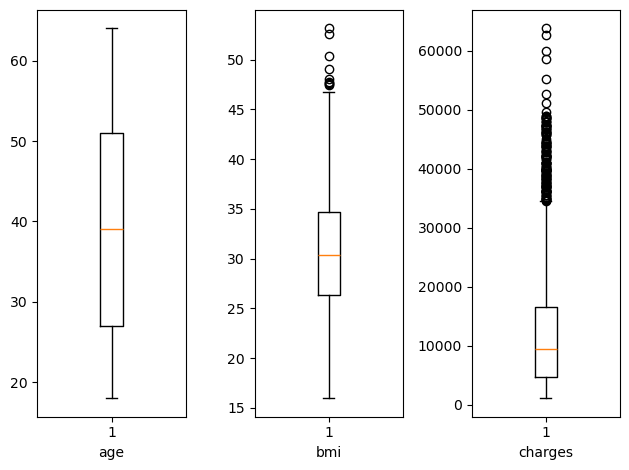

In [120]:
import matplotlib.pyplot as plt

plt.subplot(1,3,1)
plt.boxplot(dataset['age'])
plt.xlabel('age')

plt.subplot(1,3,2)
plt.boxplot(dataset['bmi'])
plt.xlabel('bmi')

plt.subplot(1,3,3)
plt.boxplot(dataset['charges'])
plt.xlabel('charges')

plt.tight_layout()
plt.show()

In [121]:
# outlier treatent:
# IQR Method
Q1 = dataset['bmi'].quantile(0.25)
Q3 = dataset['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
higher = Q3 + 1.5 * IQR

dataset['bmi'] = dataset['bmi'].clip(lower,higher)
dataset['bmi']

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

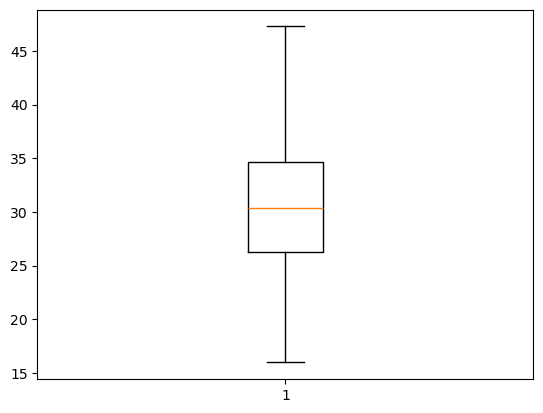

In [122]:
plt.boxplot(dataset['bmi'])
plt.show()

In [123]:
# columns 'charges' ---> log Transform:

import numpy as np
dataset['charges_log'] = np.log1p(dataset['charges'])
dataset['charges_log']

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges_log, Length: 1338, dtype: float64

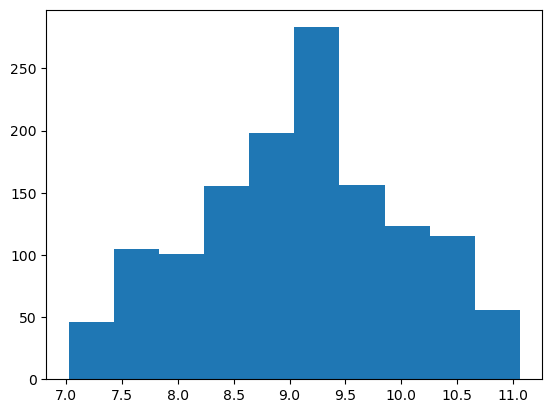

In [124]:
plt.hist(dataset['charges_log'])
plt.show()

In [125]:
# Split output and input:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'charges_log'],
      dtype='object')

In [126]:
independent = dataset[['age', 'bmi', 'children','sex_male','smoker_yes']]
dependent = dataset['charges_log']

In [127]:
# Split train and test:
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size = 0.3,random_state = 0)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size = 0.3,random_state = 0)

In [128]:
# pipeline_scaling_modelselection:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
pipe = Pipeline([('scale',StandardScaler()),
           ('model',DecisionTreeRegressor(random_state=0)
          )])

In [130]:
param_grid = {
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [None, 'sqrt', 'log2']
}

In [132]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [134]:
grid.fit(x_train,y_train)
print("Best parameters:", grid.best_params_)
print("Best CV R² score:", grid.best_score_)

Best parameters: {'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}
Best CV R² score: 0.8047236563685534


In [150]:
best_model = grid.best_estimator_

y_train_pred = best_model.predict(x_train)
from sklearn.metrics import r2_score
train_r2_score = r2_score(y_train,y_train_pred)

y_test_pred = best_model.predict(x_test)
test_r2_score = r2_score(y_test, y_test_pred)

In [152]:
print(f"Train R²: {train_r2_score}")
print(f"Test R²: {test_r2_score}")

Train R²: 0.84189366975058
Test R²: 0.8319458539914688
